In [ ]:
# import torch
# import torch.nn as nn

# class CNNLSTM(nn.Module):
#     def __init__(self, input_dim=103, seq_len=10, cnn_channels=64, lstm_hidden=128):
#         super().__init__()

#         self.seq_len = seq_len
#         self.input_dim = input_dim

#         # CNN expects (batch, channels, seq_len)
#         self.cnn = nn.Sequential(
#             nn.Conv1d(in_channels=input_dim, out_channels=cnn_channels, kernel_size=3, padding=1),
#             nn.ReLU(),
#             nn.MaxPool1d(kernel_size=2),  # seq_len → seq_len / 2
#         )

#         # LSTM expects (batch, seq_len, channels)
#         lstm_input_dim = cnn_channels

#         self.lstm = nn.LSTM(
#             input_size=lstm_input_dim,
#             hidden_size=lstm_hidden,
#             batch_first=True
#         )

#         self.fc = nn.Linear(lstm_hidden, 1)

#     def forward(self, x):
#         # x: (batch, seq_len, features)
#         x = x.permute(0, 2, 1)  # → (batch, features, seq_len)

#         x = self.cnn(x)  # → (batch, cnn_channels, seq_len/2)
#         x = x.permute(0, 2, 1)  # → (batch, seq_len/2, cnn_channels)

#         out, _ = self.lstm(x)  # → (batch, seq_len/2, hidden)
#         out = out[:, -1, :]    # last timestep

#         out = self.fc(out)
#         return out

import torch
import torch.nn as nn

class CNNLSTM(nn.Module):
    def __init__(self, input_dim, cnn_channels=64, lstm_hidden=64):
        super().__init__()

        # CNN over temporal axis (NO pooling)
        self.cnn = nn.Sequential(
            nn.Conv1d(
                in_channels=input_dim,
                out_channels=cnn_channels,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU()
        )

        self.lstm = nn.LSTM(
            input_size=cnn_channels,
            hidden_size=lstm_hidden,
            batch_first=True
        )

        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, x):
        # x: (batch, seq_len, features)
        x = x.permute(0, 2, 1)      # (batch, features, seq_len)
        x = self.cnn(x)             # (batch, cnn_channels, seq_len)
        x = x.permute(0, 2, 1)      # (batch, seq_len, cnn_channels)
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :]).squeeze(1)


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import os

# from cnn_lstm_model import CNNLSTM


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

EPOCHS = 80
BATCH = 32
LR = 1e-3
SEQ_LEN = 10


# =========================================================
# Convert tabular features into sliding window sequences
# =========================================================
def make_sequence_dataset(X, y, seq_len):
    n = len(X)

    # Auto-adjust seq_len if dataset is too small
    if n <= seq_len:
        new_seq = max(1, n - 1)
        print(f"[WARN] Dataset too small: len(X)={n}, seq_len={seq_len}. "
              f"Auto-adjusting seq_len → {new_seq}")
        seq_len = new_seq

    Xs, ys = [], []
    for i in range(n - seq_len):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len])

    return np.array(Xs), np.array(ys)



# =========================================================
# TRAIN SINGLE CNN+LSTM
# =========================================================
# def train_cnn_lstm(X_train, y_train, X_valid, y_valid, input_dim, target_name):
#     model = CNNLSTM(input_dim=input_dim, seq_len=SEQ_LEN).to(DEVICE)
#     opt = torch.optim.Adam(model.parameters(), lr=LR)
#     loss_fn = nn.MSELoss()

#     train_ds = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).float().unsqueeze(1))
#     valid_ds = TensorDataset(torch.tensor(X_valid).float(), torch.tensor(y_valid).float().unsqueeze(1))

#     train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
#     valid_loader = DataLoader(valid_ds, batch_size=BATCH)

#     best_loss = float("inf")
#     save_path = f"../outputs/models/cnn_lstm_model_{target_name}.pt"

#     for epoch in tqdm(range(1, EPOCHS+1), desc=f"CNN+LSTM-{target_name}"):

#         # ---------------- train ----------------
#         model.train()
#         tr_losses = []
#         for xb, yb in train_loader:
#             xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#             opt.zero_grad()
#             pred = model(xb)
#             loss = loss_fn(pred, yb)
#             loss.backward()
#             opt.step()
#             tr_losses.append(loss.item())

#         # ---------------- valid ----------------
#         model.eval()
#         va_losses = []
#         with torch.no_grad():
#             for xb, yb in valid_loader:
#                 xb, yb = xb.to(DEVICE), yb.to(DEVICE)
#                 pred = model(xb)
#                 loss = loss_fn(pred, yb)
#                 va_losses.append(loss.item())

#         val_loss = np.mean(va_losses)
#         train_loss = np.mean(tr_losses)

#         tqdm.write(f"Epoch {epoch}: Train={train_loss:.4f}  Valid={val_loss:.4f}")

#         if val_loss < best_loss:
#             best_loss = val_loss
#             torch.save(model.state_dict(), save_path)
#             tqdm.write(f"✔ Saved best CNN+LSTM → {save_path}")

#     return model


# =========================================================
# Prediction function
# =========================================================
def predict(model, X):
    model.eval()
    with torch.no_grad():
        X = torch.tensor(X).float().to(DEVICE)
        return model(X).cpu().numpy().flatten()


In [ ]:
def plot_predictions(y_true, y_pred, model_name, target, showImage=False):

    plt.figure(figsize=(10, 5))
    plt.plot(y_true, label="Actual", linewidth=2)
    plt.plot(y_pred, label="Predicted", linewidth=2)
    plt.title(f"{model_name} — Predicted vs Actual ({target})")
    plt.xlabel("Sample Index")
    plt.ylabel(target)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.legend()

    out = f"../outputs/plots/cnn_lstm_pred_vs_actual_{target}.png"
    os.makedirs("../outputs/plots/", exist_ok=True)
    plt.savefig(out, dpi=300)

    if showImage:
        plt.show()
    else:
        plt.close()


In [ ]:
import time

def evaluate_cnn_lstm_edge(model_path, input_dim, seq_len=SEQ_LEN):

    model = CNNLSTM(input_dim=input_dim, seq_len=seq_len)
    model.load_state_dict(torch.load(model_path, map_location="cpu"))
    model.eval()

    # Params
    params = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / (1024**2)

    # FLOPs (approx.)
    flops = params * 2  # rough

    # Latency test
    dummy = torch.randn(1, seq_len, input_dim)

    runs = 200
    warm = 20

    for _ in range(warm):
        _ = model(dummy)

    t0 = time.perf_counter()
    for _ in range(runs):
        _ = model(dummy)
    t1 = time.perf_counter()

    latency_ms = ((t1 - t0) / runs) * 1000

    # Energy estimate
    assumed_power = 2.0  # watts
    energy_j = (latency_ms / 1000) * assumed_power

    return {
        "Params": params,
        "Model Size (MB)": size_mb,
        "FLOPs": flops,
        "Latency (ms)": latency_ms,
        "Energy Estimated (J)": energy_j,
    }


In [ ]:
import numpy as np
import pandas as pd

TARGET_KEYWORDS = {
    "Throughput": ["throughput", "avgthroughput", "throughput(mbps)", "perf_throughput"],
    "Latency": ["latency", "avglatency", "latency(ms)", "perf_latency"],
    "Loss": ["loss", "packetloss", "perf_loss"]
}

def detect_target_column(df, target_name):
    keywords = TARGET_KEYWORDS[target_name]
    cols = df.columns.tolist()

    # Lowercase columns for matching
    lower_map = {c.lower(): c for c in cols}

    for kw in keywords:
        for lc, orig in lower_map.items():
            if kw in lc:
                return orig

    raise KeyError(f"No column found for target '{target_name}'. Available columns:\n{cols}")


def extract_xy(df: pd.DataFrame, target_name="Throughput"):

    # 1. Detect target column automatically
    target_col = detect_target_column(df, target_name)

    # 2. Keep numeric columns
    df_num = df.select_dtypes(include=[np.number]).copy()

    if target_col not in df_num.columns:
        raise KeyError(
            f"Detected target '{target_col}' exists but is NOT numeric.\n"
            f"Numeric columns:\n{df_num.columns.tolist()}"
        )

    # 3. Feature columns = numeric except target
    feature_cols = [c for c in df_num.columns if c != target_col]

    # 4. Extract arrays
    X = df_num[feature_cols].fillna(0).values.astype(np.float32)
    y = df_num[target_col].fillna(0).values.astype(np.float32)

    input_dim = X.shape[1]

    return X, y, input_dim


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import pandas as pd
import os

# from cnn_lstm_model import CNNLSTM
# from utils.extract_xy import extract_xy
# from utils.make_sequence_dataset import make_sequence_dataset


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPOCHS = 80
BATCH = 32
LR = 1e-3
SEQ_LEN = 10


def train_cnn_lstm(target_name="Throughput"):

    # ---------------------------------------------------------
    # Load splits
    # ---------------------------------------------------------
    df_train = pd.read_csv("../outputs/datasets/train.csv")
    df_valid = pd.read_csv("../outputs/datasets/valid.csv")
    df_test  = pd.read_csv("../outputs/datasets/test.csv")

    X_train, y_train, input_dim = extract_xy(df_train, target_name)
    X_valid, y_valid, _         = extract_xy(df_valid, target_name)
    X_test,  y_test, _          = extract_xy(df_test,  target_name)

    # Build sequences
    Xtr, ytr = make_sequence_dataset(X_train, y_train, SEQ_LEN)
    Xva, yva = make_sequence_dataset(X_valid, y_valid, SEQ_LEN)
    Xte, yte = make_sequence_dataset(X_test,  y_test,  SEQ_LEN)

    # ---------------------------------------------------------
    # Build model
    # ---------------------------------------------------------
    model = CNNLSTM(input_dim=input_dim, seq_len=SEQ_LEN).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    train_loader = DataLoader(
        TensorDataset(torch.tensor(Xtr).float(), torch.tensor(ytr).float().unsqueeze(1)),
        batch_size=BATCH,
        shuffle=True
    )

    valid_loader = DataLoader(
        TensorDataset(torch.tensor(Xva).float(), torch.tensor(yva).float().unsqueeze(1)),
        batch_size=BATCH
    )

    best_loss = float("inf")
    save_path = f"../outputs/models/cnn_lstm_model_{target_name.lower()}.pt"

    # ---------------------------------------------------------
    # Training loop
    # ---------------------------------------------------------
    for epoch in tqdm(range(1, EPOCHS+1), desc=f"CNN+LSTM-{target_name}"):

        # Train
        model.train()
        tr_losses = []
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            tr_losses.append(loss.item())

        # Validate
        model.eval()
        va_losses = []
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                pred = model(xb)
                loss = loss_fn(pred, yb)
                va_losses.append(loss.item())

        val_loss = np.mean(va_losses)
        train_loss = np.mean(tr_losses)
        tqdm.write(f"Epoch {epoch}: Train={train_loss:.4f}  Valid={val_loss:.4f}")

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), save_path)
            tqdm.write(f"✔ Saved best CNN+LSTM → {save_path}")

    # ---------------------------------------------------------
    # Predict on test set
    # ---------------------------------------------------------
    model.eval()
    with torch.no_grad():
        y_pred = model(torch.tensor(Xte).float().to(DEVICE)).cpu().numpy().flatten()

    # Save predictions
    out_csv = f"../outputs/models/predictions/cnn_lstm_{target_name.lower()}.csv"
    os.makedirs("../outputs/models/predictions/", exist_ok=True)
    pd.DataFrame({"y_true": yte, "y_pred": y_pred}).to_csv(out_csv, index=False)

    return yte, y_pred, save_path


In [ ]:
DATA_DIR  = "../outputs/datasets/"
MODEL_DIR = "../outputs/models/"
PRED_DIR  = "../outputs/models/predictions/"
WINDOW_SIZE = 1 
EPOCHS = 80
PATIENCE = 10
LR = 1e-3
BATCH_SIZE = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PRED_DIR, exist_ok=True)

def load_split_data():
    df_train = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
    df_valid = pd.read_csv(os.path.join(DATA_DIR, "valid.csv"))
    df_test  = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))
    return df_train, df_valid, df_test

def train_single_cnn_lstm(X_train, y_train, X_valid, y_valid, input_dim, target_name):

    model = CNNLSTM(input_dim).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    loss_fn = nn.MSELoss()

    train_ds = TensorDataset(
        torch.tensor(X_train).float(),
        torch.tensor(y_train).float()
    )
    valid_ds = TensorDataset(
        torch.tensor(X_valid).float(),
        torch.tensor(y_valid).float()
    )

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)

    best_loss = float("inf")
    patience_cnt = 0

    for epoch in range(EPOCHS):

        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            pred = model(xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            opt.step()
            train_loss += loss.item()

        model.eval()
        valid_loss = 0.0
        with torch.no_grad():
            for xb, yb in valid_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                valid_loss += loss_fn(model(xb), yb).item()

        train_loss /= len(train_loader)
        valid_loss /= len(valid_loader)

        print(f"[CNN-LSTM-{target_name}] Epoch {epoch+1}/{EPOCHS} | "
              f"Train={train_loss:.4f} | Valid={valid_loss:.4f}")

        if valid_loss < best_loss:
            best_loss = valid_loss
            patience_cnt = 0
            torch.save(
                model.state_dict(),
                f"../outputs/models/cnn_lstm_model_{target_name.lower()}.pt"
            )
        else:
            patience_cnt += 1
            if patience_cnt >= PATIENCE:
                print(f"[CNN-LSTM-{target_name}] Early stopping.")
                break

    return model

def predict_cnn_lstm(model, X):
    model.eval()
    with torch.no_grad():
        X = torch.tensor(X).float().to(DEVICE)
        return model(X).cpu().numpy()


import numpy as np

TARGET_ORDER = ["Throughput", "Latency", "Loss"]

def ensure_target_dict(y, target_order=TARGET_ORDER):
    """
    Accepts:
      - dict: {"Throughput": y1, "Latency": y2, "Loss": y3}
      - ndarray/list with shape (N,3): column 0..2 correspond to target_order
      - ndarray/list with shape (N,): returns {"Throughput": y} (single target case)
    Returns:
      dict
    """
    # already correct
    if isinstance(y, dict):
        return y

    y_arr = np.asarray(y)

    # single target
    if y_arr.ndim == 1:
        return {target_order[0]: y_arr}

    # multi-target matrix
    if y_arr.ndim == 2:
        if y_arr.shape[1] < len(target_order):
            raise ValueError(
                f"y has shape {y_arr.shape}, expected at least {len(target_order)} columns for {target_order}"
            )
        return {name: y_arr[:, i] for i, name in enumerate(target_order)}

    raise TypeError(f"Unsupported y type/shape: {type(y)} / {getattr(y_arr, 'shape', None)}")



def train_cnn_lstm_pipeline():

    os.makedirs(PRED_DIR, exist_ok=True)

    # --------------------------------------------------
    # Load data
    # --------------------------------------------------
    df_train, df_valid, df_test = load_split_data()

    X_train, y_train_dict, feature_cols = extract_xy(df_train)
    X_valid, y_valid_dict, _           = extract_xy(df_valid)
    X_test,  y_test_dict, _            = extract_xy(df_test)

    input_dim = X_train.shape[1]
    print(f"CNN-LSTM input_dim = {input_dim}, WINDOW_SIZE = {WINDOW_SIZE}")

    # --------------------------------------------------
    # Loop over targets (SAME AS LSTM / GRU)
    # --------------------------------------------------
    for target_name in ["Throughput", "Latency", "Loss"]:

        print(f"\n=== CNN-LSTM training for {target_name} ===")

        y_train = y_train_dict[target_name]
        y_valid = y_valid_dict[target_name]
        y_test  = y_test_dict[target_name]

        # --------------------------------------------------
        # Build sequences
        # X*: (num_seq, WINDOW_SIZE, input_dim)
        # --------------------------------------------------
        Xtr, ytr = make_sequence_dataset(X_train, y_train, WINDOW_SIZE)
        Xva, yva = make_sequence_dataset(X_valid, y_valid, WINDOW_SIZE)
        Xte, yte = make_sequence_dataset(X_test,  y_test,  WINDOW_SIZE)

        if len(Xtr) == 0:
            print(f"[CNN-LSTM-{target_name}] Skipping — no training samples.")
            continue

        # --------------------------------------------------
        # Train model
        # --------------------------------------------------
        model = train_single_cnn_lstm(
            Xtr, ytr,
            Xva, yva,
            input_dim=input_dim,
            target_name=target_name
        )

        # --------------------------------------------------
        # Predict
        # --------------------------------------------------
        pred_valid = predict_cnn_lstm(model, Xva)
        pred_test  = predict_cnn_lstm(model, Xte)

        # --------------------------------------------------
        # Save predictions (IDENTICAL PIPE)
        # --------------------------------------------------
        pd.DataFrame({
            "y_true": yva,
            "y_pred": pred_valid
        }).to_csv(
            os.path.join(PRED_DIR, f"cnn_lstm_{target_name}_valid_predictions.csv"),
            index=False
        )

        pd.DataFrame({
            "y_true": yte,
            "y_pred": pred_test
        }).to_csv(
            os.path.join(PRED_DIR, f"cnn_lstm_{target_name}_test_predictions.csv"),
            index=False
        )

        print(f"[CNN-LSTM-{target_name}] Saved predictions (valid/test).")


In [ ]:
train_cnn_lstm_pipeline()

CNN-LSTM input_dim = 103, WINDOW_SIZE = 1

=== CNN-LSTM training for Throughput ===
[CNN-LSTM-Throughput] Epoch 1/80 | Train=0.0050 | Valid=0.0237
[CNN-LSTM-Throughput] Epoch 2/80 | Train=0.0157 | Valid=0.0117
[CNN-LSTM-Throughput] Epoch 3/80 | Train=0.0026 | Valid=0.0100
[CNN-LSTM-Throughput] Epoch 4/80 | Train=0.0018 | Valid=0.0082
[CNN-LSTM-Throughput] Epoch 5/80 | Train=0.0012 | Valid=0.0045
[CNN-LSTM-Throughput] Epoch 6/80 | Train=0.0006 | Valid=0.0031
[CNN-LSTM-Throughput] Epoch 7/80 | Train=0.0005 | Valid=0.0068
[CNN-LSTM-Throughput] Epoch 8/80 | Train=0.0008 | Valid=0.0085
[CNN-LSTM-Throughput] Epoch 9/80 | Train=0.0021 | Valid=0.0072
[CNN-LSTM-Throughput] Epoch 10/80 | Train=0.0014 | Valid=0.0050
[CNN-LSTM-Throughput] Epoch 11/80 | Train=0.0009 | Valid=0.0018
[CNN-LSTM-Throughput] Epoch 12/80 | Train=0.0001 | Valid=0.0014
[CNN-LSTM-Throughput] Epoch 13/80 | Train=0.0003 | Valid=0.0011
[CNN-LSTM-Throughput] Epoch 14/80 | Train=0.0004 | Valid=0.0010
[CNN-LSTM-Throughput] Epoch 1

In [ ]:
train_cnn_lstm(target_name="Throughput")

[WARN] Dataset too small: len(X)=5, seq_len=10. Auto-adjusting seq_len → 4
[WARN] Dataset too small: len(X)=6, seq_len=10. Auto-adjusting seq_len → 5
[WARN] Dataset too small: len(X)=5, seq_len=10. Auto-adjusting seq_len → 4


CNN+LSTM-Throughput:  10%|█         | 8/80 [00:00<00:00, 74.73it/s]

Epoch 1: Train=0.0000  Valid=0.0000
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_throughput.pt
Epoch 2: Train=0.0014  Valid=0.0027
Epoch 3: Train=0.0026  Valid=0.0051
Epoch 4: Train=0.0004  Valid=0.0420
Epoch 5: Train=0.0001  Valid=0.0419
Epoch 6: Train=0.0004  Valid=0.0409
Epoch 7: Train=0.0001  Valid=0.0624
Epoch 8: Train=0.0000  Valid=0.0702
Epoch 9: Train=0.0001  Valid=0.0588
Epoch 10: Train=0.0030  Valid=0.0655
Epoch 11: Train=0.0014  Valid=0.0692
Epoch 12: Train=0.0004  Valid=0.1045
Epoch 13: Train=0.0000  Valid=0.1227
Epoch 14: Train=0.0001  Valid=0.1421


CNN+LSTM-Throughput:  10%|█         | 8/80 [00:00<00:00, 74.73it/s]

Epoch 15: Train=0.0006  Valid=0.1426


...

CNN+LSTM-Throughput:  82%|████████▎ | 66/80 [00:00<00:00, 92.29it/s]

Epoch 72: Train=0.0000  Valid=0.2016
Epoch 73: Train=0.0000  Valid=0.2019


CNN+LSTM-Throughput: 100%|██████████| 80/80 [00:00<00:00, 86.84it/s]


Epoch 74: Train=0.0000  Valid=0.2021
Epoch 75: Train=0.0000  Valid=0.2022
Epoch 76: Train=0.0000  Valid=0.2020
Epoch 77: Train=0.0000  Valid=0.2017
Epoch 78: Train=0.0000  Valid=0.2014
Epoch 79: Train=0.0000  Valid=0.2010
Epoch 80: Train=0.0000  Valid=0.2007


(array([0.313615], dtype=float32),
 array([-0.31001738], dtype=float32),
 '../outputs/models/cnn_lstm_model_throughput.pt')

In [ ]:
# train_cnn_lstm(target_name="Latency")

[WARN] Dataset too small: len(X)=5, seq_len=10. Auto-adjusting seq_len → 4
[WARN] Dataset too small: len(X)=6, seq_len=10. Auto-adjusting seq_len → 5
[WARN] Dataset too small: len(X)=5, seq_len=10. Auto-adjusting seq_len → 4


CNN+LSTM-Latency:   0%|          | 0/80 [00:00<?, ?it/s]

Epoch 1: Train=236.0965  Valid=322.7871


CNN+LSTM-Latency:   5%|▌         | 4/80 [00:00<00:07,  9.71it/s]

✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 2: Train=231.7674  Valid=318.2092
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 3: Train=230.9890  Valid=316.2732
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 4: Train=227.7853  Valid=315.0775
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 5: Train=223.2074  Valid=311.3359
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 6: Train=221.7135  Valid=310.5046
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 7: Train=220.7376  Valid=306.2863
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 8: Train=219.4017  Valid=304.7216
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt


...

CNN+LSTM-Latency:  89%|████████▉ | 71/80 [00:02<00:00, 41.12it/s]

✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 67: Train=165.5122  Valid=254.5481
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 68: Train=164.6960  Valid=253.8165
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 69: Train=163.8828  Valid=253.0869
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 70: Train=163.0727  Valid=252.3594
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 71: Train=162.2657  Valid=251.6338
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 72: Train=161.4618  Valid=250.9102
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 73: Train=160.6609  Valid=250.1886
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 74: Train=159.8631  Valid=249.4689
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 75: Train=159.0683  Valid=248.7513


CNN+LSTM-Latency: 100%|██████████| 80/80 [00:02<00:00, 32.50it/s]


✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 76: Train=158.2766  Valid=248.0356
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 77: Train=157.4878  Valid=247.3218
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 78: Train=156.7021  Valid=246.6100
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 79: Train=155.2526  Valid=245.8997
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt
Epoch 80: Train=154.4696  Valid=245.1908
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_latency.pt


(array([40.2553], dtype=float32),
 array([2.4526923], dtype=float32),
 '../outputs/models/cnn_lstm_model_latency.pt')

In [ ]:
# train_cnn_lstm(target_name="Loss")

[WARN] Dataset too small: len(X)=5, seq_len=10. Auto-adjusting seq_len → 4
[WARN] Dataset too small: len(X)=6, seq_len=10. Auto-adjusting seq_len → 5
[WARN] Dataset too small: len(X)=5, seq_len=10. Auto-adjusting seq_len → 4


CNN+LSTM-Loss:   2%|▎         | 2/80 [00:00<00:04, 17.07it/s]

Epoch 1: Train=7985.5449  Valid=7549.9819
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 2: Train=7960.1216  Valid=7551.2534
Epoch 3: Train=7952.2437  Valid=7512.9067
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt


Epoch 4: Train=7964.3872  Valid=7509.5835
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 5: Train=7941.2324  Valid=7504.4790
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 6: Train=7934.7178  Valid=7486.6514


CNN+LSTM-Loss:  11%|█▏        | 9/80 [00:00<00:02, 27.82it/s]

...

CNN+LSTM-Loss:  88%|████████▊ | 70/80 [00:02<00:00, 42.15it/s]

✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 71: Train=7566.3320  Valid=7271.5254
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 72: Train=7561.5825  Valid=7268.2612
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 73: Train=7556.8369  Valid=7264.9976


CNN+LSTM-Loss: 100%|██████████| 80/80 [00:02<00:00, 31.57it/s]

✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 74: Train=7552.0942  Valid=7261.7349
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 75: Train=7547.3545  Valid=7258.4727
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 76: Train=7542.6187  Valid=7255.2114
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 77: Train=7537.8857  Valid=7251.9507
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 78: Train=7533.1558  Valid=7248.6909
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 79: Train=7528.4297  Valid=7245.4316
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt
Epoch 80: Train=7523.7065  Valid=7242.1748
✔ Saved best CNN+LSTM → ../outputs/models/cnn_lstm_model_loss.pt


(array([67.], dtype=float32),
 array([2.5724154], dtype=float32),
 '../outputs/models/cnn_lstm_model_loss.pt')

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================

PRED_DIR = "../outputs/models/predictions/"
PLOT_DIR = "../outputs/models/plots/"
os.makedirs(PLOT_DIR, exist_ok=True)

TARGETS = ["Throughput", "Latency", "Loss"]

plt.style.use("seaborn-v0_8-whitegrid")

# ============================================================
# LOAD PREDICTIONS
# ============================================================

def load_preds(metric, split):
    path = os.path.join(
        PRED_DIR,
        f"cnn_lstm_{metric}_{split}_predictions.csv"
    )
    df = pd.read_csv(path)
    return df["y_true"], df["y_pred"]

# ============================================================
# PREDICTED VS ACTUAL
# ============================================================

def plot_pred_vs_actual(y_true, y_pred, title, outfile, showImage=False):
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.6)

    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    plt.plot([lo, hi], [lo, hi], "r--", linewidth=2)

    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    print(f"Saved → {outfile}")

    if showImage:
        plt.show()
    else:
        plt.close()

# ============================================================
# TIME SERIES
# ============================================================

def plot_time_series(y_true, y_pred, title, outfile, showImage=False):
    plt.figure(figsize=(10, 5))
    plt.plot(y_true.values, label="Actual", linewidth=2)
    plt.plot(y_pred.values, label="Predicted", linestyle="--", linewidth=2)

    plt.legend()
    plt.title(title)
    plt.tight_layout()

    plt.savefig(outfile, dpi=300)
    print(f"Saved → {outfile}")

    if showImage:
        plt.show()
    else:
        plt.close()

# ============================================================
# GENERATE ALL CNN-LSTM PLOTS
# ============================================================

def generate_cnn_lstm_plots(showImage=False):

    for metric in TARGETS:

        print(f"\n=== Generating CNN-LSTM plots for {metric} ===")

        # ---------------- Validation ----------------
        yv, pv = load_preds(metric, "valid")

        plot_pred_vs_actual(
            yv, pv,
            title=f"CNN-LSTM – Predicted vs Actual ({metric}, Valid)",
            outfile=os.path.join(
                PLOT_DIR, f"cnn_lstm_{metric}_pred_valid.png"
            ),
            showImage=showImage
        )

        plot_time_series(
            yv, pv,
            title=f"CNN-LSTM – Time Series ({metric}, Valid)",
            outfile=os.path.join(
                PLOT_DIR, f"cnn_lstm_{metric}_ts_valid.png"
            ),
            showImage=showImage
        )

        # ---------------- Test ----------------
        yt, pt = load_preds(metric, "test")

        plot_pred_vs_actual(
            yt, pt,
            title=f"CNN-LSTM – Predicted vs Actual ({metric}, Test)",
            outfile=os.path.join(
                PLOT_DIR, f"cnn_lstm_{metric}_pred_test.png"
            ),
            showImage=showImage
        )

        plot_time_series(
            yt, pt,
            title=f"CNN-LSTM – Time Series ({metric}, Test)",
            outfile=os.path.join(
                PLOT_DIR, f"cnn_lstm_{metric}_ts_test.png"
            ),
            showImage=showImage
        )

    print("\nAll CNN-LSTM plots generated successfully!")



=== Generating CNN-LSTM plots for Throughput ===
Saved → ../outputs/models/plots/cnn_lstm_Throughput_pred_valid.png


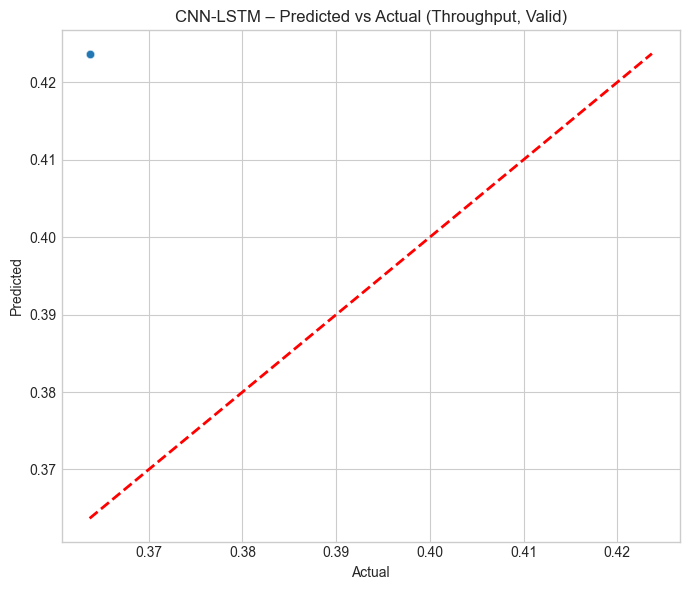

Saved → ../outputs/models/plots/cnn_lstm_Throughput_ts_valid.png


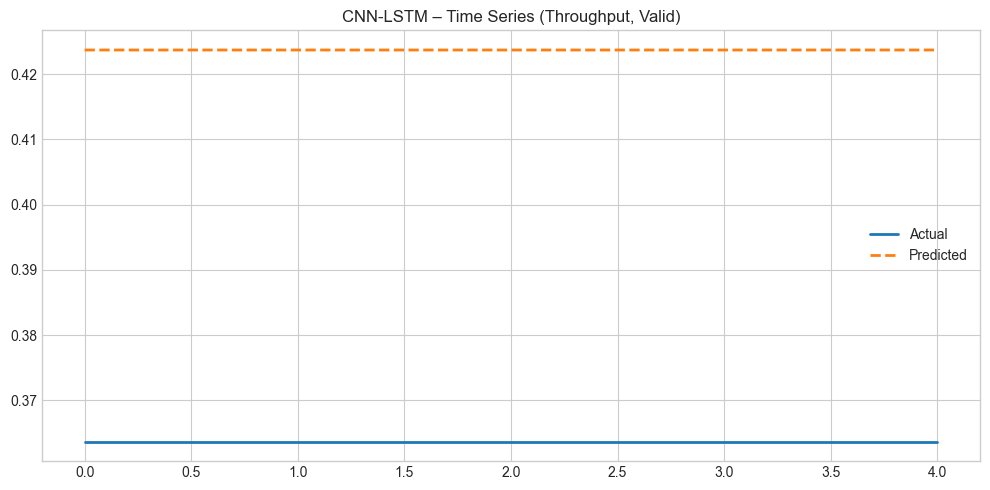

Saved → ../outputs/models/plots/cnn_lstm_Throughput_pred_test.png


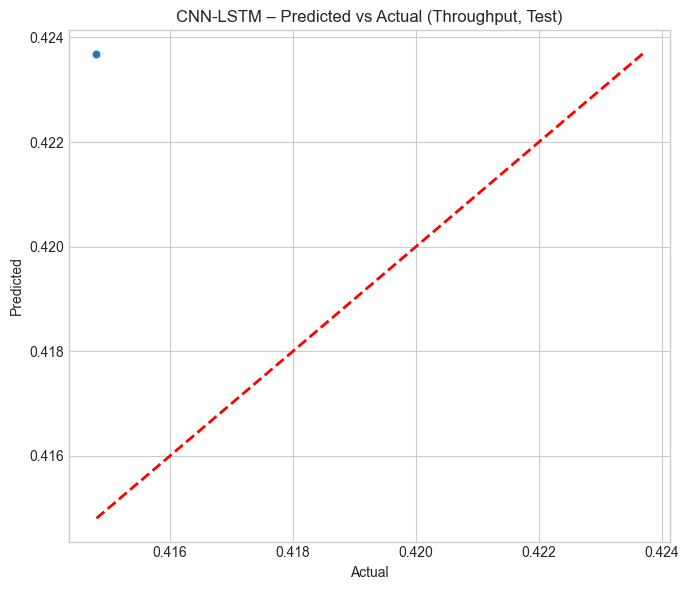

Saved → ../outputs/models/plots/cnn_lstm_Throughput_ts_test.png


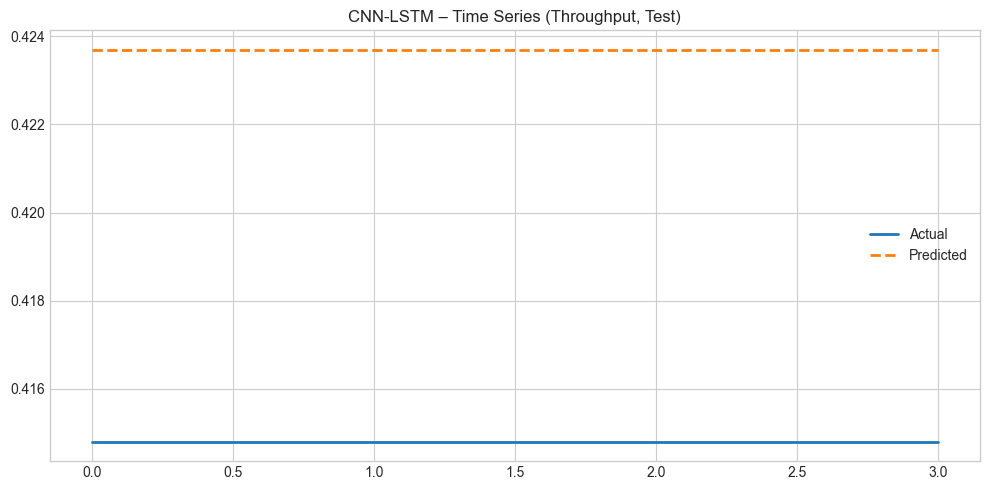


=== Generating CNN-LSTM plots for Latency ===
Saved → ../outputs/models/plots/cnn_lstm_Latency_pred_valid.png


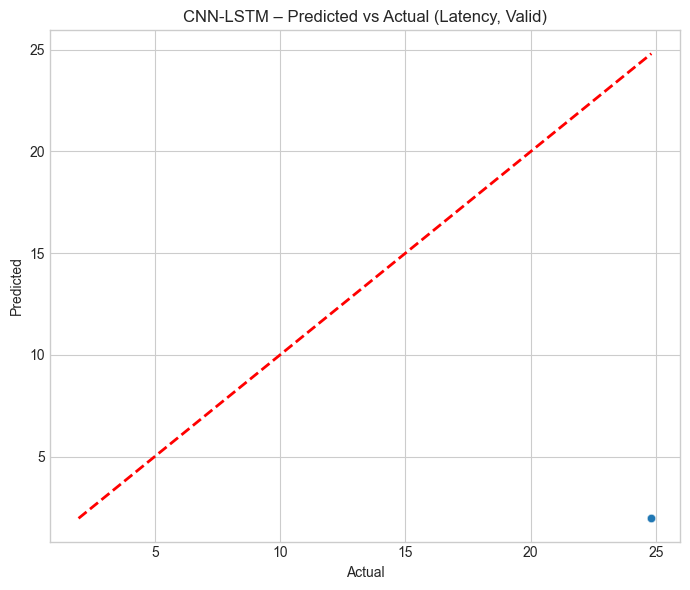

Saved → ../outputs/models/plots/cnn_lstm_Latency_ts_valid.png


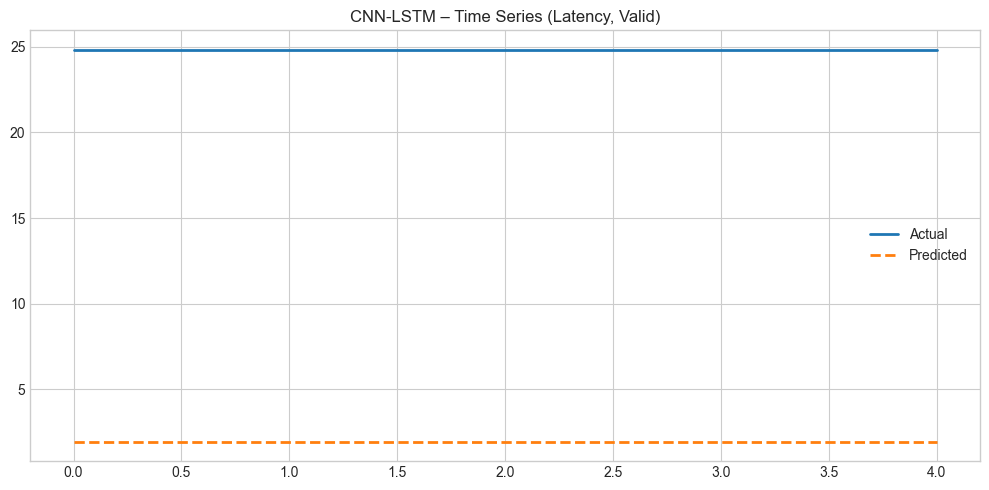

Saved → ../outputs/models/plots/cnn_lstm_Latency_pred_test.png


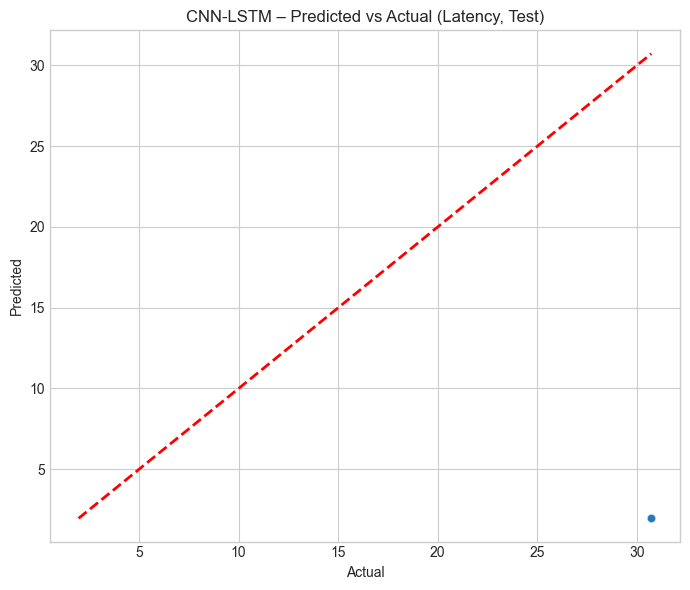

Saved → ../outputs/models/plots/cnn_lstm_Latency_ts_test.png


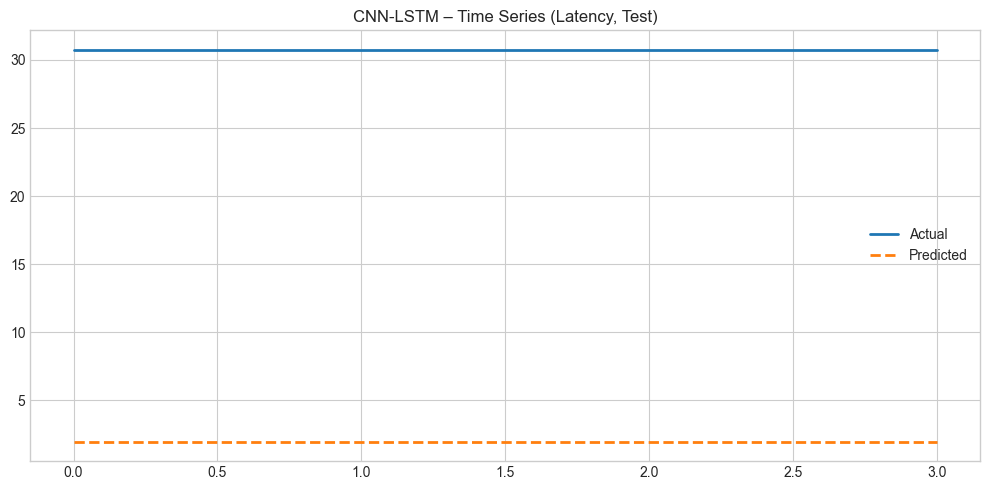


=== Generating CNN-LSTM plots for Loss ===
Saved → ../outputs/models/plots/cnn_lstm_Loss_pred_valid.png


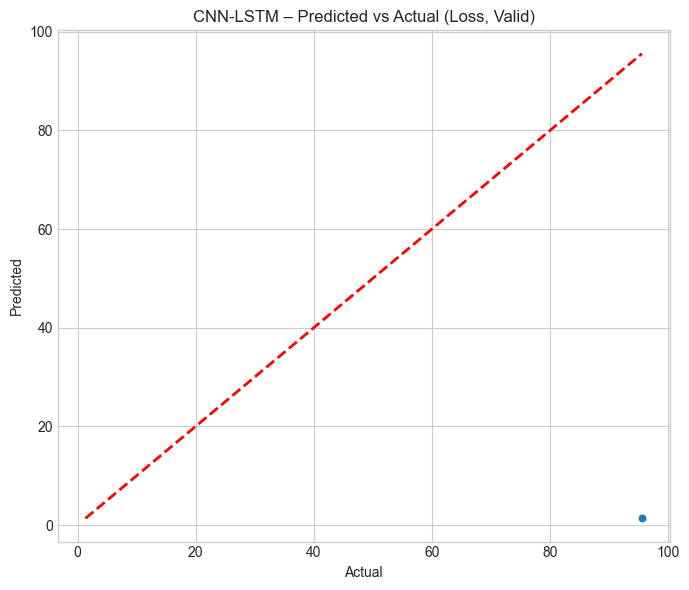

Saved → ../outputs/models/plots/cnn_lstm_Loss_ts_valid.png


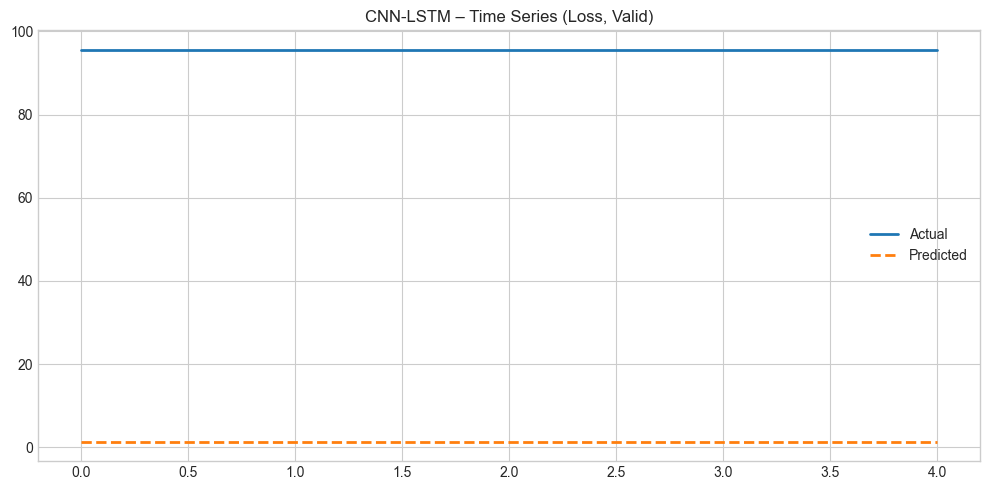

Saved → ../outputs/models/plots/cnn_lstm_Loss_pred_test.png


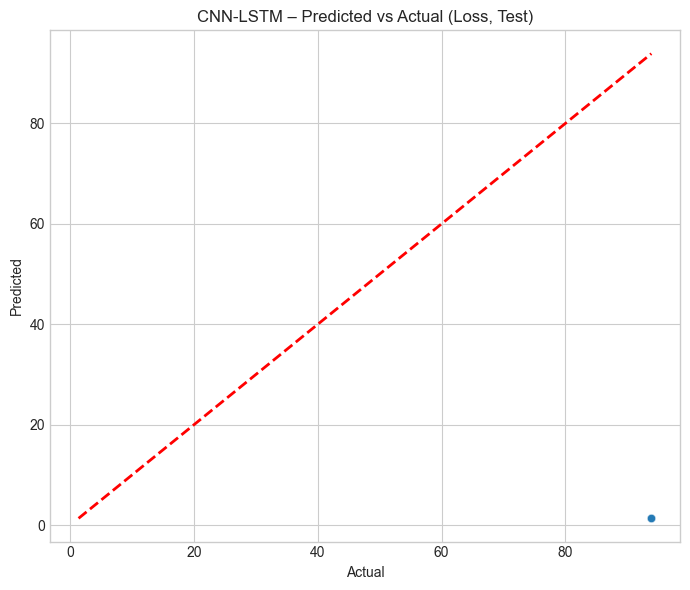

Saved → ../outputs/models/plots/cnn_lstm_Loss_ts_test.png


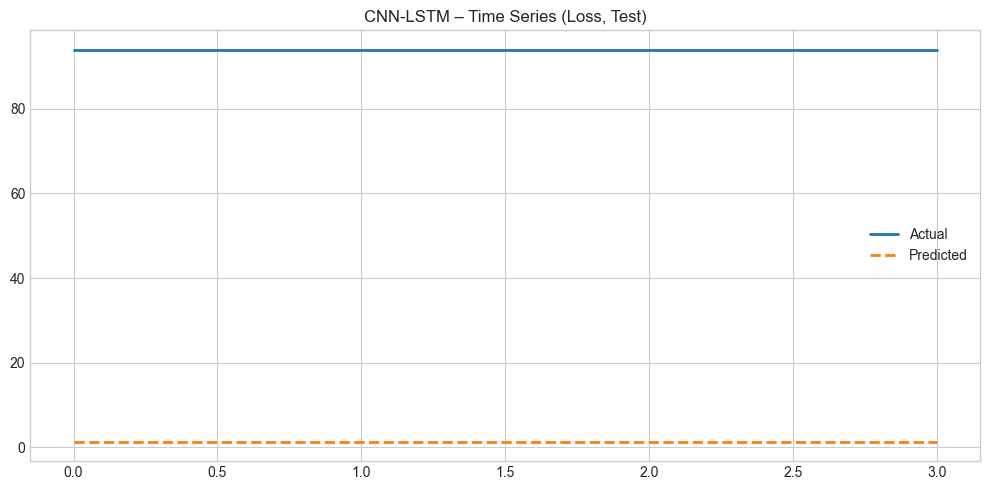


All CNN-LSTM plots generated successfully!


In [ ]:
generate_cnn_lstm_plots(showImage=True)


In [ ]:
import torch
import time
import numpy as np
# from cnn_lstm_model import CNNLSTM

def evaluate_cnn_lstm_edge(model_path, input_dim, sequence_len=10, assumed_power_W=2.0):

    model = CNNLSTM(input_dim=input_dim)
    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state)
    model.eval()

    params = sum(p.numel() for p in model.parameters())
    size_mb = params * 4 / (1024**2)
    flops = params * 2  # approx

    dummy = torch.randn(1, sequence_len, input_dim)

    warm = 20
    runs = 200

    for _ in range(warm):
        model(dummy)

    t0 = time.perf_counter()
    for _ in range(runs):
        model(dummy)
    t1 = time.perf_counter()

    latency_ms = ((t1 - t0) / runs) * 1000
    energy_j = (latency_ms / 1000) * assumed_power_W

    activation_bytes = sequence_len * input_dim * 4

    return {
        "Parameters": params,
        "Model Size (MB)": size_mb,
        "FLOPs": flops,
        "Latency (ms)": latency_ms,
        "Energy Estimated (J)": energy_j,
        "Peak Activation Memory (Bytes)": activation_bytes,
        "Model Path": model_path,
    }


In [ ]:

input_dim = 103
model_path = "../outputs/models/cnn_lstm_model_throughput.pt"

metrics = evaluate_cnn_lstm_edge(model_path, input_dim, sequence_len=1)

for k, v in metrics.items():
    print(f"{k}: {v}")

Parameters: 53185
Model Size (MB): 0.20288467407226562
FLOPs: 106370
Latency (ms): 1.8468405003659427
Energy Estimated (J): 0.0036936810007318853
Peak Activation Memory (Bytes): 412
Model Path: ../outputs/models/cnn_lstm_model_throughput.pt


In [ ]:

input_dim = 103
model_path = "../outputs/models/cnn_lstm_model_latency.pt"
metrics = evaluate_cnn_lstm_edge(model_path, input_dim, sequence_len=1)

for k, v in metrics.items():
    print(f"{k}: {v}")

Parameters: 53185
Model Size (MB): 0.20288467407226562
FLOPs: 106370
Latency (ms): 1.2921199999982491
Energy Estimated (J): 0.0025842399999964983
Peak Activation Memory (Bytes): 412
Model Path: ../outputs/models/cnn_lstm_model_latency.pt


In [ ]:

input_dim = 103
model_path = "../outputs/models/cnn_lstm_model_loss.pt"
metrics = evaluate_cnn_lstm_edge(model_path, input_dim, sequence_len=1)

for k, v in metrics.items():
    print(f"{k}: {v}")

Parameters: 53185
Model Size (MB): 0.20288467407226562
FLOPs: 106370
Latency (ms): 0.7645400002365932
Energy Estimated (J): 0.0015290800004731863
Peak Activation Memory (Bytes): 412
Model Path: ../outputs/models/cnn_lstm_model_loss.pt
